In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

catalogo_productos = pd.read_csv('../data/raw/catalogo_productos.csv')
especificaciones_cajas = pd.read_csv('../data/raw/especificaciones_cajas.csv')
operaciones_planta = pd.read_csv('../data/raw/operaciones_planta.csv')
procurement_cajas = pd.read_csv('../data/raw/procurement_cajas.csv')

productos_joined_cajas = pd.read_csv('../data/processed/producto_joined_cajas_clean.csv')

---
embed-resources: True
format:
    html:
        page-layout: full
        fontsize: 18px

title: 'Exploration'
author: 'Lorenzo Marquesini'
warning: False
toc: False
---

## catalogo_productos
El catálogo de productos es la tabla central e incluye un identificador único por SKU (codigo_producto), su descripción comercial, peso neto por caja (peso_neto_caja) y la clave que lo vincula al tipo de caja asignado (caja_tipo_id).

In [52]:
catalogo_productos

,codigo_producto,descripcion_producto,ingrediente_forma,tipo_proyecto,subcategoria,categoria,tamaño_corte,peso_neto_caja,tamaño_paquete,cantidad_paquetes,peso_neto_paquete,caja_tipo_id
0,BR0001,"5 bolsas de 2,5 kg | Bastones rectos de brocol...",Bastones rectos de brocoli,Estacional,Bastones clasicos - Reserva Privada,Bastones clasicos,Fino,12.50,"5 X 2,5 KG",5.0,2.50,a23eeef1c0cd8cfd40b780d65382034a
1,BR0002,Espirales de brocoli - clasico - Caja de 13 pa...,Espirales de brocoli,Forma estable,Bastones clasicos - Sigilo,Bastones clasicos,Forma,9.75,"13 X 0,75 KG",13.0,0.75,3256a5fed07b421a92abee44a3d93243
2,BR0003,Gajos de brocoli - sazonado - Caja de 13 packs...,Gajos de brocoli,Forma estable,Bastones clasicos - Sigilo,Bastones clasicos,Forma,9.75,"13 X 0,75 KG",13.0,0.75,4f08f853cf7f9be28571df66a50bc322
3,BR0004,Bastones rectos de brocoli - crocante - Caja d...,Bastones rectos de brocoli,Estacional,Bastones clasicos - Sigilo,Bastones clasicos,Grueso,11.25,"9 X 1,25 KG",9.0,1.25,c96df5913565ba35f3e02e744c9a6dde
4,BR0005,"13 bolsas de 0,75 kg | Espirales de brocoli si...",Espirales de brocoli,Forma estable,Bastones clasicos - Sigilo,Bastones clasicos,Forma,9.75,"13 X 0,75 KG",13.0,0.75,eb4895380ccaa410da0fefb6f12b197b
...,...,...,...,...,...,...,...,...,...,...,...,...
422,BR0417,Mix crujiente de brocoli - clasico - Caja de 1...,Mix crujiente de brocoli,Forma estable,Bastones clasicos - Sigilo,Bastones clasicos,Forma,8.25,"11 X 0,75 KG",11.0,0.75,563a3fa61d441769163b35905be8987d
423,BR0418,"BonsaiGreen Mix crujiente de brocoli 11 x 0,75 kg",Mix crujiente de brocoli,Forma estable,Bastones clasicos - Sigilo,Bastones clasicos,Forma,8.25,"11X0,8 KG",NaN,NaN,563a3fa61d441769163b35905be8987d
424,BR0419,"5 bolsas de 2,5 kg | Bastones rectos de brocol...",Bastones rectos de brocoli,Estacional,Bastones clasicos - Reserva Privada,Bastones clasicos,Corte steak,12.50,"5 X 2,5 KG",5.0,2.50,3cdb44bb6e06ba2151d665a0c599b894
425,BR0420,"5 bolsas de 2,5 kg | Bastones rectos de brocol...",Bastones rectos de brocoli,Estacional,Bastones clasicos - Reserva Privada,Bastones clasicos,Medio,12.50,"5 X 2,5 KG",5.0,2.50,a130566667d4be7bb38053adaefea0af


## especificaciones_cajas
Las especificaciones de cajas contienen las dimensiones interiores y exteriores de cada tipo (caja_interior_largo, caja_interior_ancho, caja_interior_alto, caja_exterior_largo, caja_exterior_ancho, caja_exterior_alto), junto con los parámetros de apilado en pallet (cantidad_cajas_alto, cantidad_cajas_largo, cantidad_cajas_ancho, cantidad_cajas_total, utilizacion).

In [53]:
especificaciones_cajas

,caja_tipo_id,caja_grosor_mm,caja_interior_largo,caja_interior_ancho,caja_interior_alto,caja_exterior_largo,caja_exterior_ancho,caja_exterior_alto,pallet_alto,pallet_ancho,pallet_largo,cantidad_cajas_alto,cantidad_cajas_largo,cantidad_cajas_ancho,cantidad_cajas_total,utilizacion
0,02cf77de65b70dd77905e2e33d78478f,2.7,395.0,296.0,291.0,400.0,301.4,296.4,1800,800,1200,6.0,2.0,3.0,36.0,0.744458
1,082c1cdb42b1abd201403ca33ca11ef0,4.1,383.0,248.0,189.0,391.2,256.2,197.2,1800,800,1200,9.0,2.0,4.0,72.0,0.823519
2,0835ff365412a67b720a19713ec250f3,4.1,386.0,286.0,278.0,394.2,294.2,286.2,1800,800,1200,6.0,2.0,4.0,48.0,0.921990
3,0b72571a5bb7429ce7de424547e8d27d,4.1mm,386.0,286.0,174.0,394.2,294.2,182.2,1800,800,1200,9.0,2.0,4.0,72.0,0.880433
4,10c5f9edbe2c87186bcdeb991fe8d902,4.6,380.0,252.0,228.0,389.2,261.2,237.2,1800,800,1200,7.0,2.0,4.0,56.0,0.781457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,fa8da38322149b23e14a120e71d38975,2.7,393.0,255.0,235.0,398.4,260.4,240.4,1800,800,1200,7.0,2.0,4.0,56.0,0.808238
200,fc6931875b8384c7bacd18bb4699795f,2.7,393.0,255.0,219.0,398.4,260.4,224.4,1800,800,1200,8.0,2.0,4.0,64.0,0.862223
201,fe503fe59c48da80878a0b8f7ad58dcb,4.1,383.0,248.0,204.0,391.2,256.2,212.2,1800,800,1200,8.0,2.0,4.0,NaN,0.787698
202,fe7802fb3f92b710413a4de88233a3f7,4.1,388.0,288.0,174.0,396.2,296.2,182.2,1800,800,1200,9.0,2.0,4.0,72.0,0.890916


## operaciones_planta
Las operaciones de planta registran los volúmenes anuales por SKU (volumen_producto_total) y los costos logísticos asociados (costo_pallets_total, costo_total).

In [54]:
operaciones_planta.info()

<class 'pandas.DataFrame'>
RangeIndex: 427 entries, 0 to 426
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   codigo_producto                              427 non-null    str    
 1   volumen_producto_canal_servicios_comida      427 non-null    int64  
 2   volumen_producto_canal_minorista             427 non-null    int64  
 3   volumen_producto_canal_cadenas_corporativas  427 non-null    int64  
 4   volumen_producto_canal_otros                 427 non-null    int64  
 5   volumen_producto_total                       427 non-null    int64  
 6   volumen_producto_planta_buenos_aires         427 non-null    int64  
 7   volumen_producto_planta_curitiba             427 non-null    int64  
 8   volumen_producto_planta_santiago             427 non-null    int64  
 9   volumen_producto_planta_monterrey            427 non-null    int64  
 10  volumen_produ

In [55]:
operaciones_planta

,codigo_producto,volumen_producto_canal_servicios_comida,volumen_producto_canal_minorista,volumen_producto_canal_cadenas_corporativas,volumen_producto_canal_otros,volumen_producto_total,volumen_producto_planta_buenos_aires,volumen_producto_planta_curitiba,volumen_producto_planta_santiago,volumen_producto_planta_monterrey,...,costo_total_planta_santiago,costo_total_planta_monterrey,costo_total_planta_bakersfield,costo_pallets_planta_buenos_aires,costo_pallets_planta_curitiba,costo_pallets_planta_santiago,costo_pallets_planta_monterrey,costo_pallets_planta_bakersfield,costo_pallets_total,costo_total
0,BR0001,1537892,0,0,8721,1546613,0,1431746,26583,88284,...,17278.950,51646.14,0.00,0,5369100,99750,331200,0,5800050,720369.520
1,BR0002,0,139211,0,0,139211,0,139211,0,0,...,0.000,0.00,0.00,0,580050,0,0,0,580050,66821.280
2,BR0003,0,172506,0,0,172506,0,0,0,0,...,0.000,0.00,89703.12,0,0,0,0,323550,323550,89703.120
3,BR0004,0,271715,0,0,271715,0,0,0,0,...,0.000,0.00,130423.20,0,0,0,0,970500,970500,130423.200
4,BR0005,0,7586,0,0,7586,0,7586,0,0,...,0.000,0.00,0.00,0,23850,0,0,0,23850,3944.720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
422,BR0417,2761,0,0,0,2761,0,0,2761,0,...,1974.115,0.00,0.00,0,0,7500,0,0,7500,1974.115
423,BR0418,3942,0,0,0,3942,0,0,3942,0,...,2818.530,0.00,0.00,0,0,10650,0,0,10650,2818.530
424,BR0419,43300,0,0,0,43300,0,0,0,43300,...,0.000,25980.00,0.00,0,0,0,108300,0,108300,25980.000
425,BR0420,205852,0,0,0,205852,0,24227,0,181625,...,0.000,76282.50,0.00,0,56850,0,425700,0,482550,87911.460


## procurement_cajas
El archivo de compras consolida los volúmenes por tipo de caja y planta (volumen_tipo_planta_*), y define los precios unitarios resultantes de aplicar el grosor del cartón y el descuento por volumen correspondiente.

In [56]:
procurement_cajas.info()

<class 'pandas.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   caja_tipo_id                        204 non-null    str    
 1   volumen_tipo_planta_buenos_aires    204 non-null    int64  
 2   volumen_tipo_planta_curitiba        204 non-null    int64  
 3   volumen_tipo_planta_santiago        204 non-null    int64  
 4   volumen_tipo_planta_monterrey       204 non-null    int64  
 5   volumen_tipo_planta_bakersfield     204 non-null    int64  
 6   costo_unitario_base                 204 non-null    float64
 7   costo_total_base                    204 non-null    float64
 8   costo_unitario_planta_buenos_aires  204 non-null    str    
 9   costo_unitario_planta_curitiba      204 non-null    str    
 10  costo_unitario_planta_santiago      204 non-null    str    
 11  costo_unitario_planta_monterrey     204 non-null    str 

<hr>

# Reconstrucción de Baseline

In [57]:
productos_joined_cajas

,codigo_producto,descripcion_producto,ingrediente_forma,tipo_proyecto,subcategoria,categoria,tamaño_corte,peso_neto_caja,tamaño_paquete,cantidad_paquetes,...,tamaño_paquete_peso,peso_calculado_caja,peso_caja_ok,cantidad_ok_tamano,max_cajas_en_ancho_pallet,max_cajas_en_largo_pallet,max_cajas_en_alto_pallet,max_cajas_total_pallet,cantidad_cajas_total_ok,exceso_cajas
0,BR0001,"5 bolsas de 2,5 kg | Bastones rectos de brocol...",Bastones rectos de brocoli,Estacional,Bastones clasicos - Reserva Privada,Bastones clasicos,Fino,12.50,"5x2,5kg",5,...,2.50,12.50,True,True,2.0,4.0,5.0,40.0,True,0.0
1,BR0002,Espirales de brocoli - clasico - Caja de 13 pa...,Espirales de brocoli,Forma estable,Bastones clasicos - Sigilo,Bastones clasicos,Forma,9.75,"13x0,75kg",13,...,0.75,9.75,True,True,2.0,3.0,6.0,36.0,True,0.0
2,BR0003,Gajos de brocoli - sazonado - Caja de 13 packs...,Gajos de brocoli,Forma estable,Bastones clasicos - Sigilo,Bastones clasicos,Forma,9.75,"13x0,75kg",13,...,0.75,9.75,True,True,2.0,4.0,10.0,80.0,True,0.0
3,BR0004,Bastones rectos de brocoli - crocante - Caja d...,Bastones rectos de brocoli,Estacional,Bastones clasicos - Sigilo,Bastones clasicos,Grueso,11.25,"9x1,25kg",9,...,1.25,11.25,True,True,2.0,3.0,7.0,42.0,True,0.0
4,BR0005,"13 bolsas de 0,75 kg | Espirales de brocoli si...",Espirales de brocoli,Forma estable,Bastones clasicos - Sigilo,Bastones clasicos,Forma,9.75,"13x0,75kg",13,...,0.75,9.75,True,True,2.0,4.0,6.0,48.0,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
422,BR0417,Mix crujiente de brocoli - clasico - Caja de 1...,Mix crujiente de brocoli,Forma estable,Bastones clasicos - Sigilo,Bastones clasicos,Forma,8.25,"11x0,75kg",11,...,0.75,8.25,True,True,2.0,4.0,7.0,56.0,True,0.0
423,BR0418,"BonsaiGreen Mix crujiente de brocoli 11 x 0,75 kg",Mix crujiente de brocoli,Forma estable,Bastones clasicos - Sigilo,Bastones clasicos,Forma,8.25,"11x0,8kg",11,...,0.80,8.25,True,True,2.0,4.0,7.0,56.0,True,0.0
424,BR0419,"5 bolsas de 2,5 kg | Bastones rectos de brocol...",Bastones rectos de brocoli,Estacional,Bastones clasicos - Reserva Privada,Bastones clasicos,Corte steak,12.50,"5x2,5kg",5,...,2.50,12.50,True,True,2.0,3.0,10.0,60.0,True,0.0
425,BR0420,"5 bolsas de 2,5 kg | Bastones rectos de brocol...",Bastones rectos de brocoli,Estacional,Bastones clasicos - Reserva Privada,Bastones clasicos,Medio,12.50,"5x2,5kg",5,...,2.50,12.50,True,True,2.0,4.0,8.0,64.0,True,0.0


In [58]:
productos_joined_cajas.columns

Index(['codigo_producto', 'descripcion_producto', 'ingrediente_forma',
       'tipo_proyecto', 'subcategoria', 'categoria', 'tamaño_corte',
       'peso_neto_caja', 'tamaño_paquete', 'cantidad_paquetes',
       'peso_neto_paquete', 'caja_tipo_id', 'checksums', 'caja_grosor_mm',
       'caja_interior_largo', 'caja_interior_ancho', 'caja_interior_alto',
       'caja_exterior_largo', 'caja_exterior_ancho', 'caja_exterior_alto',
       'pallet_alto', 'pallet_ancho', 'pallet_largo', 'cantidad_cajas_alto',
       'cantidad_cajas_largo', 'cantidad_cajas_ancho', 'cantidad_cajas_total',
       'utilizacion', 'tamaño_paquete_cantidad', 'tamaño_paquete_peso',
       'peso_calculado_caja', 'peso_caja_ok', 'cantidad_ok_tamano',
       'max_cajas_en_ancho_pallet', 'max_cajas_en_largo_pallet',
       'max_cajas_en_alto_pallet', 'max_cajas_total_pallet',
       'cantidad_cajas_total_ok', 'exceso_cajas'],
      dtype='str')

<hr>

# Costos

Asumo

* costo_total: Costo por packaging
* costo_pallets_total: Costo por envio (150 USD x pallet verifica)

In [59]:
operaciones_planta.head()

,codigo_producto,volumen_producto_canal_servicios_comida,volumen_producto_canal_minorista,volumen_producto_canal_cadenas_corporativas,volumen_producto_canal_otros,volumen_producto_total,volumen_producto_planta_buenos_aires,volumen_producto_planta_curitiba,volumen_producto_planta_santiago,volumen_producto_planta_monterrey,...,costo_total_planta_santiago,costo_total_planta_monterrey,costo_total_planta_bakersfield,costo_pallets_planta_buenos_aires,costo_pallets_planta_curitiba,costo_pallets_planta_santiago,costo_pallets_planta_monterrey,costo_pallets_planta_bakersfield,costo_pallets_total,costo_total
0,BR0001,1537892,0,0,8721,1546613,0,1431746,26583,88284,...,17278.95,51646.14,0.00,0,5369100,99750,331200,0,5800050,720369.52
1,BR0002,0,139211,0,0,139211,0,139211,0,0,...,0.00,0.00,0.00,0,580050,0,0,0,580050,66821.28
2,BR0003,0,172506,0,0,172506,0,0,0,0,...,0.00,0.00,89703.12,0,0,0,0,323550,323550,89703.12
3,BR0004,0,271715,0,0,271715,0,0,0,0,...,0.00,0.00,130423.20,0,0,0,0,970500,970500,130423.20
4,BR0005,0,7586,0,0,7586,0,7586,0,0,...,0.00,0.00,0.00,0,23850,0,0,0,23850,3944.72


In [60]:
operaciones_planta[['costo_total','costo_pallets_total']].sum().round()

costo_total             30166294.0
costo_pallets_total    179068800.0
dtype: float64

Todos envios en la misma region?

In [61]:
df = operaciones_planta[['cantidad_pallets_total',"costo_pallets_total"]].copy()
df['costo_por_pallet'] = df['costo_pallets_total'] / df['cantidad_pallets_total']
df['costo_por_pallet'].unique()

array([150.])

<hr>

## Costo total = packiging + envio
## $209.235.094 = $30.166.294 + $179.068.800

In [62]:
total_cost_baseline = 209235094
packaging_baseline = 30166294
freight_baseline = 179068800

<hr>

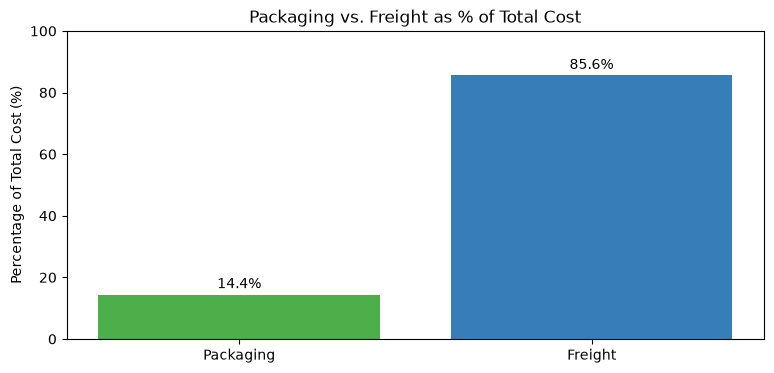

In [63]:
# Calculate percentages
packaging_pct = packaging_baseline / total_cost_baseline * 100
freight_pct = freight_baseline / total_cost_baseline * 100

# Data for barchart
labels = ['Packaging', 'Freight']
percentages = [packaging_pct, freight_pct]

# Plot
plt.figure(figsize=(9,4))
bars = plt.bar(labels, percentages, color=['#4daf4a', '#377eb8'])
plt.ylabel('Percentage of Total Cost (%)')
plt.title('Packaging vs. Freight as % of Total Cost')
plt.ylim(0, 100)
for bar, pct in zip(bars, percentages):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{pct:.1f}%", ha='center', va='bottom')
plt.show()

<hr>

# Capacidad Ociosa

In [64]:
especificaciones_cajas

,caja_tipo_id,caja_grosor_mm,caja_interior_largo,caja_interior_ancho,caja_interior_alto,caja_exterior_largo,caja_exterior_ancho,caja_exterior_alto,pallet_alto,pallet_ancho,pallet_largo,cantidad_cajas_alto,cantidad_cajas_largo,cantidad_cajas_ancho,cantidad_cajas_total,utilizacion
0,02cf77de65b70dd77905e2e33d78478f,2.7,395.0,296.0,291.0,400.0,301.4,296.4,1800,800,1200,6.0,2.0,3.0,36.0,0.744458
1,082c1cdb42b1abd201403ca33ca11ef0,4.1,383.0,248.0,189.0,391.2,256.2,197.2,1800,800,1200,9.0,2.0,4.0,72.0,0.823519
2,0835ff365412a67b720a19713ec250f3,4.1,386.0,286.0,278.0,394.2,294.2,286.2,1800,800,1200,6.0,2.0,4.0,48.0,0.921990
3,0b72571a5bb7429ce7de424547e8d27d,4.1mm,386.0,286.0,174.0,394.2,294.2,182.2,1800,800,1200,9.0,2.0,4.0,72.0,0.880433
4,10c5f9edbe2c87186bcdeb991fe8d902,4.6,380.0,252.0,228.0,389.2,261.2,237.2,1800,800,1200,7.0,2.0,4.0,56.0,0.781457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,fa8da38322149b23e14a120e71d38975,2.7,393.0,255.0,235.0,398.4,260.4,240.4,1800,800,1200,7.0,2.0,4.0,56.0,0.808238
200,fc6931875b8384c7bacd18bb4699795f,2.7,393.0,255.0,219.0,398.4,260.4,224.4,1800,800,1200,8.0,2.0,4.0,64.0,0.862223
201,fe503fe59c48da80878a0b8f7ad58dcb,4.1,383.0,248.0,204.0,391.2,256.2,212.2,1800,800,1200,8.0,2.0,4.0,NaN,0.787698
202,fe7802fb3f92b710413a4de88233a3f7,4.1,388.0,288.0,174.0,396.2,296.2,182.2,1800,800,1200,9.0,2.0,4.0,72.0,0.890916


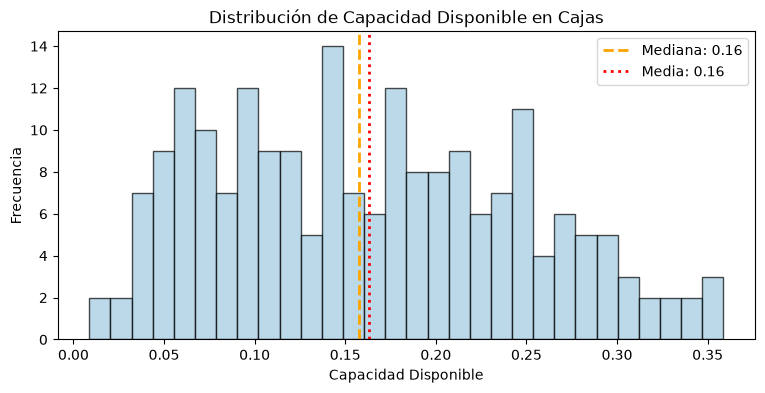

In [65]:
# Vamos a graficar la capacidad disponible: 1 - utilizacion

capacidad_disponible = 1 - especificaciones_cajas['utilizacion'].dropna()

plt.figure(figsize=(9,4))
plt.hist(capacidad_disponible, bins=30, color="#9ecae1", edgecolor="black", alpha=0.7)
plt.xlabel('Capacidad Disponible')
plt.ylabel('Frecuencia')
plt.title('Distribución de Capacidad Disponible en Cajas')

# Calcular mediana y media
median_disp = capacidad_disponible.median()
mean_disp = capacidad_disponible.mean()

# Dibujar líneas y agregar leyendas
plt.axvline(median_disp, color='orange', linestyle='dashed', linewidth=2, label=f"Mediana: {median_disp:.2f}")
plt.axvline(mean_disp, color='red', linestyle='dotted', linewidth=2, label=f"Media: {mean_disp:.2f}")

plt.legend()
plt.show()

In [66]:
productos_joined_cajas.info()

<class 'pandas.DataFrame'>
RangeIndex: 427 entries, 0 to 426
Data columns (total 39 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   codigo_producto            427 non-null    str    
 1   descripcion_producto       427 non-null    str    
 2   ingrediente_forma          427 non-null    str    
 3   tipo_proyecto              427 non-null    str    
 4   subcategoria               427 non-null    str    
 5   categoria                  427 non-null    str    
 6   tamaño_corte               427 non-null    str    
 7   peso_neto_caja             427 non-null    float64
 8   tamaño_paquete             427 non-null    str    
 9   cantidad_paquetes          427 non-null    int64  
 10  peso_neto_paquete          427 non-null    float64
 11  caja_tipo_id               427 non-null    str    
 12  checksums                  390 non-null    float64
 13  caja_grosor_mm             427 non-null    float64
 14  caja_

#### Alguna categoria usa peor la capacidad?

In [67]:
# HELPER HELPER HELPER HELPER
def boxplot_by_group(
    data,
    group_var,
    value_var="utilizacion",
    figsize=(10, 5),
    title_prefix='Distribución de Utilización de Caja por',
    xlabel='Utilización de Caja',
    ylabel=None,
    jitter=True,      # toggle jitter
    jitter_alpha=0.25 # transparency of points
):
    # Calculate medians for sorting
    order_by_median = (
        data.groupby(group_var)[value_var]
        .median()
        .sort_values(ascending=False)
        .index
    )
    plt.figure(figsize=figsize)
    if jitter:
        # Jitter the points using swarmplot
        sns.stripplot(
            data=data,
            x=value_var,
            y=group_var,
            orient="h",
            order=order_by_median,
            color="black",
            size=3,
            alpha=jitter_alpha,
            jitter=True
        )
    # Draw medians per group
    group_medians = data.groupby(group_var)[value_var].median().reindex(order_by_median)
    for y_index, (group, median_value) in enumerate(group_medians.items()):
        plt.plot(
            [median_value], [y_index],
            marker="|",
            markersize=28,
            color="red",
            markeredgewidth=4,
            label="Mediana" if y_index == 0 else None
        )
    plt.yticks(rotation=0)
    plt.xlabel(xlabel)
    if ylabel is None:
        ylabel = group_var.capitalize()
    plt.ylabel(ylabel)
    plt.title(f"{title_prefix} {group_var.capitalize()} (Solo Puntos y Mediana)")
    # Show median label only once if present
    handles, labels = plt.gca().get_legend_handles_labels()
    if "Mediana" in labels:
        plt.legend([handles[labels.index("Mediana")]], ["Mediana"])
    plt.tight_layout()
    plt.show()

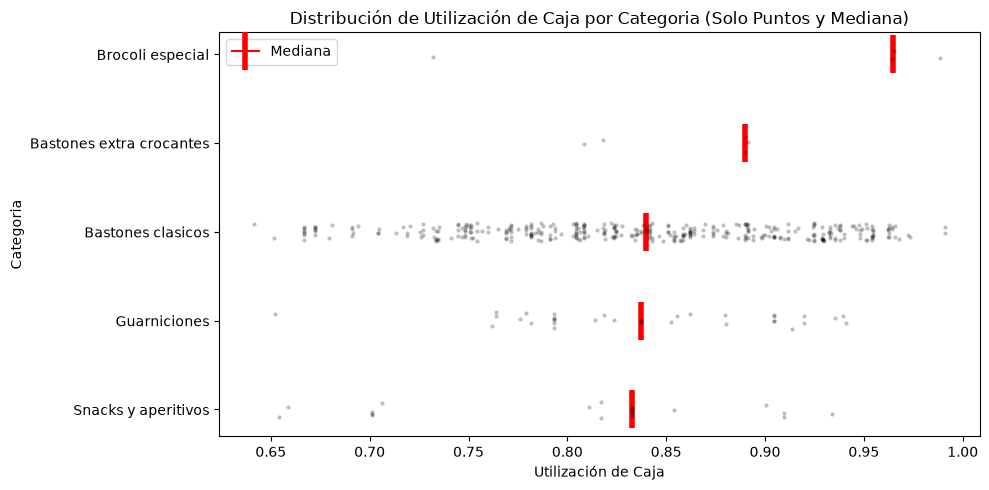

In [68]:
boxplot_by_group(productos_joined_cajas, group_var="categoria")

Alguna subcategoria?

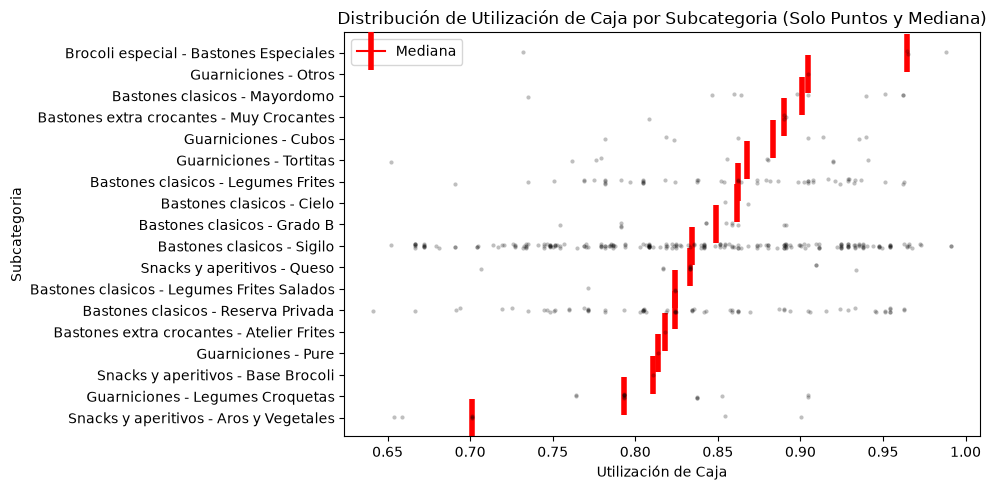

In [69]:
boxplot_by_group(productos_joined_cajas, group_var="subcategoria")

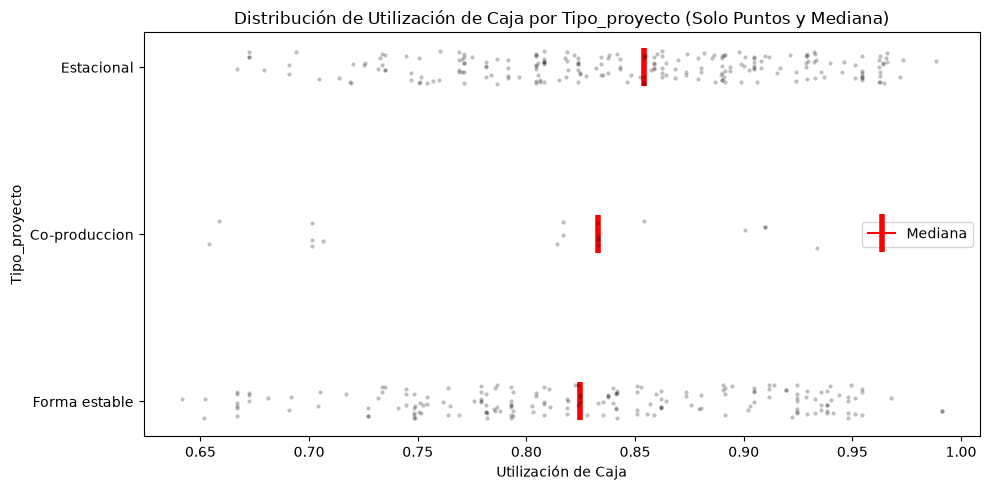

In [70]:
boxplot_by_group(productos_joined_cajas, group_var="tipo_proyecto")

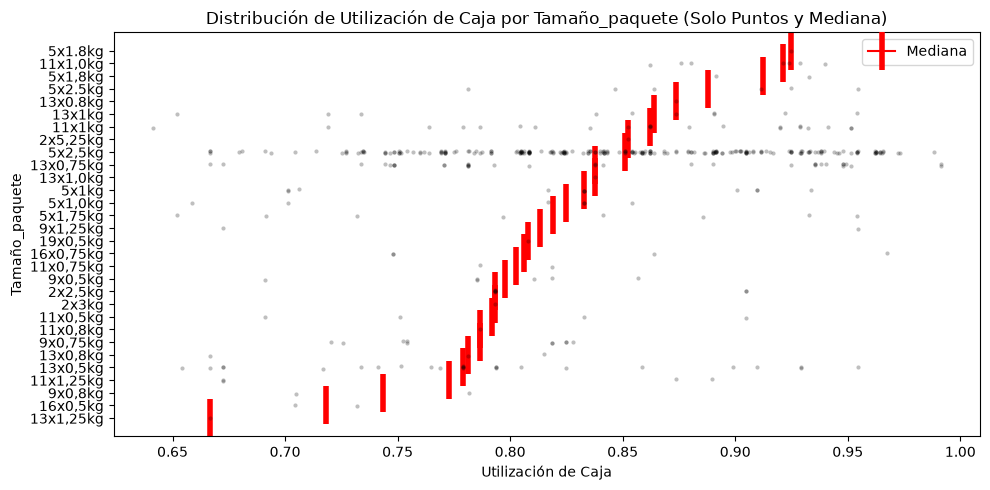

In [71]:
boxplot_by_group(productos_joined_cajas, group_var="tamaño_paquete")

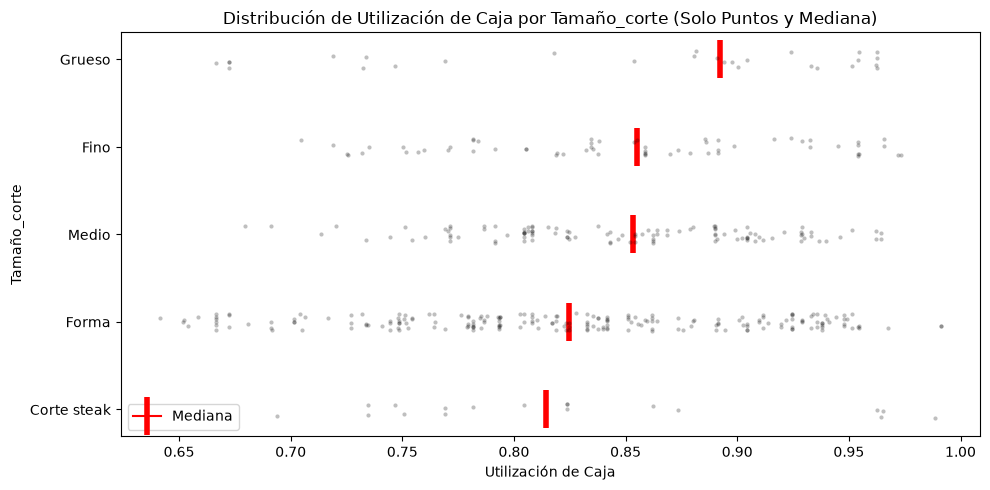

In [72]:
boxplot_by_group(productos_joined_cajas, group_var="tamaño_corte")

<hr>

# Entregable final

In [73]:
solution_df = pd.DataFrame({
    "codigo_producto": catalogo_productos['codigo_producto'],
    "caja_grosor_mm": pd.Series(dtype='object'),
    "caja_exterior_largo": pd.Series(dtype='object'),
    "caja_exterior_ancho": pd.Series(dtype='object'),
    "caja_exterior_alto": pd.Series(dtype='object')
})

solution_df

,codigo_producto,caja_grosor_mm,caja_exterior_largo,caja_exterior_ancho,caja_exterior_alto
0,BR0001,NaN,NaN,NaN,NaN
1,BR0002,NaN,NaN,NaN,NaN
2,BR0003,NaN,NaN,NaN,NaN
3,BR0004,NaN,NaN,NaN,NaN
4,BR0005,NaN,NaN,NaN,NaN
...,...,...,...,...,...
422,BR0417,NaN,NaN,NaN,NaN
423,BR0418,NaN,NaN,NaN,NaN
424,BR0419,NaN,NaN,NaN,NaN
425,BR0420,NaN,NaN,NaN,NaN


### Current solution

In [74]:
baseline_solution = pd.read_csv('../outputs/tables/00_baseline_solution.csv')
baseline_solution.head()

,codigo_producto,caja_grosor_mm,caja_exterior_largo,caja_exterior_ancho,caja_exterior_alto
0,BR0001,4.1,394.2,294.2,311.2
1,BR0002,2.7,400.0,301.4,265.4
2,BR0003,4.1,396.2,296.2,172.2
3,BR0004,2.7,400.0,301.4,229.4
4,BR0005,4.1,394.2,294.2,261.2


### Evaluator

In [75]:
import re


def _to_float(x):
    """
    Robust parser for numbers like:
    3.0, '3.0', '3,0', '3.0 mm', '4,5mm'
    """
    if pd.isna(x):
        return np.nan
    
    s = str(x).strip().replace(",", ".")
    match = re.search(r"-?\d+(\.\d+)?", s)
    
    if match is None:
        return np.nan
    
    return float(match.group(0))


def _price_factor(volume):
    if volume < 20_000:
        return 1.10
    elif volume < 50_000:
        return 1.00
    elif volume < 100_000:
        return 0.90
    elif volume < 500_000:
        return 0.80
    else:
        return 0.70


def _base_price(thickness):
    """
    Official standardized thickness prices.
    For non-standard historical thicknesses, map to the closest official tier.
    This is only for baseline calibration.
    """
    if thickness <= 3.0:
        return 0.60
    elif thickness <= 4.5:
        return 0.65
    else:
        return 0.70


def _headspace_limit_pct(thickness):
    if thickness <= 3.0:
        return 0.06
    elif thickness <= 4.5:
        return 0.08
    else:
        return 0.10


def evaluate_solution_v2(
    solution,
    productos_joined_cajas,
    operaciones_planta,
    validate_constraints=True,
    calibrate_packaging=True,
    strict=False,
    return_details=False
):
    """
    Evaluates total cost = packaging + freight.

    Important:
    - operaciones_planta['costo_total'] is treated as current packaging cost.
    - operaciones_planta['costo_pallets_total'] is treated as current freight cost.
    - If calibrate_packaging=True, packaging formula is scaled so the current assignment
      matches the observed current packaging cost.
    """

    if isinstance(solution, str):
        solution = pd.read_csv(solution)

    solution = solution.copy()
    productos = productos_joined_cajas.copy()
    ops = operaciones_planta.copy()

    required_cols = [
        "codigo_producto",
        "caja_grosor_mm",
        "caja_exterior_largo",
        "caja_exterior_ancho",
        "caja_exterior_alto"
    ]

    errors = []

    # -----------------------------
    # 1. Format validation
    # -----------------------------
    if list(solution.columns) != required_cols:
        errors.append(
            f"Invalid columns. Expected exactly {required_cols}, got {list(solution.columns)}"
        )

    if solution["codigo_producto"].duplicated().any():
        errors.append("Duplicate codigo_producto values.")

    expected = set(productos["codigo_producto"])
    submitted = set(solution["codigo_producto"])

    if expected != submitted:
        errors.append(
            f"Product mismatch. Missing={len(expected - submitted)}, Extra={len(submitted - expected)}"
        )

    # -----------------------------
    # 2. Normalize numeric fields
    # -----------------------------
    numeric_cols = [
        "caja_grosor_mm",
        "caja_exterior_largo",
        "caja_exterior_ancho",
        "caja_exterior_alto"
    ]

    for col in numeric_cols:
        solution[col] = solution[col].apply(_to_float)

    if solution[numeric_cols].isna().any().any():
        errors.append("There are non-numeric values in thickness or dimensions.")

    # -----------------------------
    # 3. Strict challenge constraints
    # -----------------------------
    allowed_thickness = {3.0, 4.5, 5.0}

    if validate_constraints:
        used_thickness = set(solution["caja_grosor_mm"].dropna().unique())

        if not used_thickness.issubset(allowed_thickness):
            errors.append(f"Invalid thickness values: {used_thickness - allowed_thickness}")

        if solution["caja_grosor_mm"].nunique() != 1:
            errors.append("Invalid: solution must use one single thickness for all boxes.")

    # -----------------------------
    # 4. Current baseline costs
    # -----------------------------
    current_packaging_cost = ops["costo_total"].sum()
    current_freight_cost = ops["costo_pallets_total"].sum()
    current_total_cost = current_packaging_cost + current_freight_cost

    # -----------------------------
    # 5. Prepare product baseline dimensions
    # -----------------------------
    base_cols = [
        "codigo_producto",
        "peso_neto_caja",
        "caja_grosor_mm",
        "caja_interior_largo",
        "caja_interior_ancho",
        "caja_interior_alto",
        "caja_exterior_largo",
        "caja_exterior_ancho",
        "caja_exterior_alto"
    ]

    base = productos[base_cols].copy()

    for col in [
        "caja_grosor_mm",
        "caja_interior_largo",
        "caja_interior_ancho",
        "caja_interior_alto",
        "caja_exterior_largo",
        "caja_exterior_ancho",
        "caja_exterior_alto"
    ]:
        base[col] = base[col].apply(_to_float)

    base = base.rename(columns={
        "caja_grosor_mm": "current_caja_grosor_mm",
        "caja_interior_largo": "current_interior_largo",
        "caja_interior_ancho": "current_interior_ancho",
        "caja_interior_alto": "current_interior_alto",
        "caja_exterior_largo": "current_exterior_largo",
        "caja_exterior_ancho": "current_exterior_ancho",
        "caja_exterior_alto": "current_exterior_alto",
    })

    df = (
        solution
        .merge(base, on="codigo_producto", how="left")
        .merge(ops, on="codigo_producto", how="left")
    )

    # -----------------------------
    # 6. Infer new internal dimensions
    # -----------------------------
    # If submitted exterior dimensions match an existing box, use its known internal dims.
    # Otherwise fallback to exterior - 2 * thickness.
    box_lookup = productos[
        [
            "caja_grosor_mm",
            "caja_exterior_largo",
            "caja_exterior_ancho",
            "caja_exterior_alto",
            "caja_interior_largo",
            "caja_interior_ancho",
            "caja_interior_alto"
        ]
    ].drop_duplicates().copy()

    for col in box_lookup.columns:
        if col != "caja_tipo_id":
            box_lookup[col] = box_lookup[col].apply(_to_float)

    box_lookup = box_lookup.rename(columns={
        "caja_interior_largo": "matched_interior_largo",
        "caja_interior_ancho": "matched_interior_ancho",
        "caja_interior_alto": "matched_interior_alto",
    })

    df = df.merge(
        box_lookup,
        on=[
            "caja_grosor_mm",
            "caja_exterior_largo",
            "caja_exterior_ancho",
            "caja_exterior_alto"
        ],
        how="left"
    )

    for dim in ["largo", "ancho", "alto"]:
        df[f"new_interior_{dim}"] = df[f"matched_interior_{dim}"]

        fallback = df[f"caja_exterior_{dim}"] - 2 * df["caja_grosor_mm"]

        df[f"new_interior_{dim}"] = df[f"new_interior_{dim}"].fillna(fallback)

    # -----------------------------
    # 7. Fit and headspace validation
    # -----------------------------
    fit_cols = []

    for dim in ["largo", "ancho", "alto"]:
        current = df[f"current_interior_{dim}"]
        new = df[f"new_interior_{dim}"]

        df[f"headspace_{dim}"] = new - current
        df[f"headspace_max_{dim}"] = np.minimum(
            df["caja_grosor_mm"].apply(_headspace_limit_pct) * new,
            40
        )

        df[f"valid_fit_{dim}"] = (
            (new >= current) &
            (new <= current * 1.10) &
            (df[f"headspace_{dim}"] <= df[f"headspace_max_{dim}"])
        )

        fit_cols.append(f"valid_fit_{dim}")

    df["valid_fit"] = df[fit_cols].all(axis=1)

    if validate_constraints:
        invalid_fit_count = int((~df["valid_fit"]).sum())
        if invalid_fit_count > 0:
            errors.append(f"Invalid fit/headspace: {invalid_fit_count} products.")
    else:
        invalid_fit_count = int((~df["valid_fit"]).sum())

    # -----------------------------
    # 8. Pallet capacity
    # -----------------------------
    # Constraint: box long side parallel to pallet short side.
    PALLET_SHORT = 800
    PALLET_LONG = 1200
    MAX_HEIGHT = 1800

    df["new_cajas_largo"] = np.floor(PALLET_SHORT / df["caja_exterior_largo"])
    df["new_cajas_ancho"] = np.floor(PALLET_LONG / df["caja_exterior_ancho"])
    df["new_cajas_alto"] = np.floor(MAX_HEIGHT / df["caja_exterior_alto"])

    df["new_cajas_por_pallet"] = (
        df["new_cajas_largo"] *
        df["new_cajas_ancho"] *
        df["new_cajas_alto"]
    )

    invalid_pallet_count = int((df["new_cajas_por_pallet"] <= 0).sum())

    if validate_constraints and invalid_pallet_count > 0:
        errors.append(f"Invalid pallet capacity: {invalid_pallet_count} products.")

    # -----------------------------
    # 9. Compression validation
    # -----------------------------
    ect_map = {
        2.5: 600,
        2.7: 730,
        3.0: 1000,
        4.1: 1200,
        4.5: 1400,
        4.6: 1450,
        4.7: 1500,
        4.8: 1550,
        5.0: 1650,
    }

    df["ECT"] = df["caja_grosor_mm"].map(ect_map)

    df["perimetro_m"] = (
        2 * (df["caja_exterior_largo"] + df["caja_exterior_ancho"]) / 1000
    )

    df["carga_max_kg"] = df["ECT"] * df["perimetro_m"] / 9.81

    df["peso_encima_kg"] = np.maximum(df["new_cajas_alto"] - 1, 0) * df["peso_neto_caja"]

    df["valid_compression"] = df["carga_max_kg"] >= df["peso_encima_kg"]

    invalid_compression_count = int((~df["valid_compression"]).sum())

    if validate_constraints and invalid_compression_count > 0:
        errors.append(f"Invalid compression: {invalid_compression_count} products.")

    # -----------------------------
    # 10. Freight cost
    # -----------------------------
    plants = [
        "buenos_aires",
        "curitiba",
        "santiago",
        "monterrey",
        "bakersfield"
    ]

    freight_cols = []
    pallet_cols = []

    for plant in plants:
        vol_col = f"volumen_producto_planta_{plant}"
        current_pallet_col = f"cantidad_pallets_planta_{plant}"
        current_cost_col = f"costo_pallets_planta_{plant}"

        new_pallet_col = f"new_pallets_planta_{plant}"
        rate_col = f"current_cost_per_pallet_{plant}"
        freight_col = f"new_freight_cost_{plant}"

        df[new_pallet_col] = np.ceil(
            df[vol_col] / df["new_cajas_por_pallet"].replace(0, np.nan)
        ).fillna(0)

        global_rate = (
            df[current_cost_col].sum() /
            df[current_pallet_col].replace(0, np.nan).sum()
        )

        df[rate_col] = (
            df[current_cost_col] /
            df[current_pallet_col].replace(0, np.nan)
        ).fillna(global_rate)

        df[freight_col] = df[new_pallet_col] * df[rate_col]

        freight_cols.append(freight_col)
        pallet_cols.append(new_pallet_col)

    df["new_freight_cost"] = df[freight_cols].sum(axis=1)
    df["new_pallets_total"] = df[pallet_cols].sum(axis=1)

    # -----------------------------
    # 11. Packaging cost
    # -----------------------------
    box_key = [
        "caja_grosor_mm",
        "caja_exterior_largo",
        "caja_exterior_ancho",
        "caja_exterior_alto"
    ]

    packaging_cols = []

    for plant in plants:
        vol_col = f"volumen_producto_planta_{plant}"

        demand = (
            df.groupby(box_key, dropna=False)[vol_col]
            .sum()
            .reset_index()
            .rename(columns={vol_col: f"box_volume_{plant}"})
        )

        demand[f"packaging_factor_{plant}"] = demand[f"box_volume_{plant}"].apply(_price_factor)
        demand[f"raw_unit_packaging_cost_{plant}"] = (
            demand["caja_grosor_mm"].apply(_base_price) *
            demand[f"packaging_factor_{plant}"]
        )

        df = df.merge(
            demand[box_key + [f"raw_unit_packaging_cost_{plant}"]],
            on=box_key,
            how="left"
        )

        cost_col = f"raw_packaging_cost_{plant}"
        df[cost_col] = df[vol_col] * df[f"raw_unit_packaging_cost_{plant}"]
        packaging_cols.append(cost_col)

    df["raw_packaging_cost"] = df[packaging_cols].sum(axis=1)

    raw_packaging_total = df["raw_packaging_cost"].sum()

    # Calibrate so that packaging scale matches the observed current packaging magnitude.
    # This avoids the bug where packaging becomes only ~400k instead of ~30M.
    if calibrate_packaging:
        # Build current assignment as reference
        current_solution = productos[
            [
                "codigo_producto",
                "caja_grosor_mm",
                "caja_exterior_largo",
                "caja_exterior_ancho",
                "caja_exterior_alto"
            ]
        ].copy()

        for col in current_solution.columns:
            if col != "codigo_producto":
                current_solution[col] = current_solution[col].apply(_to_float)

        current_ref = current_solution.merge(ops, on="codigo_producto", how="left")

        ref_packaging_cols = []

        for plant in plants:
            vol_col = f"volumen_producto_planta_{plant}"

            demand_ref = (
                current_ref.groupby(
                    [
                        "caja_grosor_mm",
                        "caja_exterior_largo",
                        "caja_exterior_ancho",
                        "caja_exterior_alto"
                    ],
                    dropna=False
                )[vol_col]
                .sum()
                .reset_index()
                .rename(columns={vol_col: f"box_volume_{plant}"})
            )

            demand_ref[f"factor_{plant}"] = demand_ref[f"box_volume_{plant}"].apply(_price_factor)
            demand_ref[f"raw_unit_cost_{plant}"] = (
                demand_ref["caja_grosor_mm"].apply(_base_price) *
                demand_ref[f"factor_{plant}"]
            )

            current_ref = current_ref.merge(
                demand_ref[
                    [
                        "caja_grosor_mm",
                        "caja_exterior_largo",
                        "caja_exterior_ancho",
                        "caja_exterior_alto",
                        f"raw_unit_cost_{plant}"
                    ]
                ],
                on=[
                    "caja_grosor_mm",
                    "caja_exterior_largo",
                    "caja_exterior_ancho",
                    "caja_exterior_alto"
                ],
                how="left"
            )

            ref_col = f"raw_packaging_ref_{plant}"
            current_ref[ref_col] = current_ref[vol_col] * current_ref[f"raw_unit_cost_{plant}"]
            ref_packaging_cols.append(ref_col)

        raw_current_packaging = current_ref[ref_packaging_cols].sum(axis=1).sum()
        packaging_scale = current_packaging_cost / raw_current_packaging
    else:
        packaging_scale = 1.0

    df["new_packaging_cost"] = df["raw_packaging_cost"] * packaging_scale

    # -----------------------------
    # 12. Final total
    # -----------------------------
    df["new_total_cost"] = df["new_packaging_cost"] + df["new_freight_cost"]

    new_packaging_cost = df["new_packaging_cost"].sum()
    new_freight_cost = df["new_freight_cost"].sum()
    new_total_cost = df["new_total_cost"].sum()

    savings = current_total_cost - new_total_cost
    savings_pct = savings / current_total_cost

    n_box_types = df[box_key].drop_duplicates().shape[0]

    result = {
        "valid": len(errors) == 0,
        "errors": errors,

        "n_box_types": int(n_box_types),

        "current_packaging_cost": current_packaging_cost,
        "current_freight_cost": current_freight_cost,
        "current_total_cost": current_total_cost,

        "new_packaging_cost": new_packaging_cost,
        "new_freight_cost": new_freight_cost,
        "new_total_cost": new_total_cost,

        "savings": savings,
        "savings_pct": savings_pct,

        "packaging_scale": packaging_scale,

        "invalid_fit_count": invalid_fit_count,
        "invalid_pallet_count": invalid_pallet_count,
        "invalid_compression_count": invalid_compression_count,
    }

    if strict and len(errors) > 0:
        raise ValueError(result)

    if return_details:
        return result, df

    return result

In [76]:
result, detail = evaluate_solution_v2(
    baseline_solution,
    productos_joined_cajas,
    operaciones_planta,
    validate_constraints=True,
    strict=False,
    return_details=True
)

result['savings_pct']

np.float64(0.0)

<hr>

Naive

In [77]:
baseline_solution

,codigo_producto,caja_grosor_mm,caja_exterior_largo,caja_exterior_ancho,caja_exterior_alto
0,BR0001,4.1,394.2,294.2,311.2
1,BR0002,2.7,400.0,301.4,265.4
2,BR0003,4.1,396.2,296.2,172.2
3,BR0004,2.7,400.0,301.4,229.4
4,BR0005,4.1,394.2,294.2,261.2
...,...,...,...,...,...
422,BR0417,4.1,391.2,256.2,242.2
423,BR0418,4.1,391.2,256.2,242.2
424,BR0419,2.7,400.0,301.4,178.4
425,BR0420,2.7,398.4,260.4,209.4


In [78]:
solution_caja_grosor_mm = baseline_solution.copy()
solution_caja_grosor_mm['caja_grosor_mm'] = 3
result, detail = evaluate_solution_v2(
    solution_caja_grosor_mm,
    productos_joined_cajas,
    operaciones_planta,
    validate_constraints=True,
    strict=False,
    return_details=True
)

result

{'valid': False,
 'errors': ['Invalid fit/headspace: 165 products.'],
 'n_box_types': 204,
 'current_packaging_cost': np.float64(30166293.939999998),
 'current_freight_cost': np.int64(179068800),
 'current_total_cost': np.float64(209235093.94),
 'new_packaging_cost': np.float64(28631082.27777428),
 'new_freight_cost': np.float64(179068800.0),
 'new_total_cost': np.float64(207699882.27777427),
 'savings': np.float64(1535211.6622257233),
 'savings_pct': np.float64(0.007337257021835728),
 'packaging_scale': np.float64(0.9957360465224698),
 'invalid_fit_count': 165,
 'invalid_pallet_count': 0,
 'invalid_compression_count': 0}

In [79]:
solution_2 = pd.read_csv('../outputs/tables/01_minimize_box_size.csv')
solution_2

,codigo_producto,caja_grosor_mm,caja_exterior_largo,caja_exterior_ancho,caja_exterior_alto
0,BR0001,3,386.0,286.0,303.0
1,BR0002,3,395.0,296.0,260.0
2,BR0003,3,388.0,288.0,164.0
3,BR0004,3,395.0,296.0,224.0
4,BR0005,3,386.0,286.0,253.0
...,...,...,...,...,...
422,BR0417,3,383.0,248.0,234.0
423,BR0418,3,383.0,248.0,234.0
424,BR0419,3,395.0,296.0,173.0
425,BR0420,3,393.0,255.0,204.0


In [80]:
solution_2['caja_grosor_mm'] = 3

result, detail = evaluate_solution_v2(
    solution_2,
    productos_joined_cajas,
    operaciones_planta,
    validate_constraints=True,
    strict=False,
    return_details=True
)

result

{'valid': False,
 'errors': ['Invalid fit/headspace: 427 products.'],
 'n_box_types': 200,
 'current_packaging_cost': np.float64(30166293.939999998),
 'current_freight_cost': np.int64(179068800),
 'current_total_cost': np.float64(209235093.94),
 'new_packaging_cost': np.float64(28623821.56967025),
 'new_freight_cost': np.float64(166833450.0),
 'new_total_cost': np.float64(195457271.56967026),
 'savings': np.float64(13777822.370329738),
 'savings_pct': np.float64(0.06584852526833118),
 'packaging_scale': np.float64(0.9957360465224698),
 'invalid_fit_count': 427,
 'invalid_pallet_count': 0,
 'invalid_compression_count': 0}

<hr>

## Baseline baseline valid solution

* Un solo global thickness (3, 4.5, 5)

* Un producto una caja (427 filas)

* La caja asignada debe ser dimensionalmente feasible. (Debe entrar y ser compatibility)


In [81]:
valid_solution = baseline_solution.copy()
valid_solution['caja_grosor_mm'] = 3
valid_solution

,codigo_producto,caja_grosor_mm,caja_exterior_largo,caja_exterior_ancho,caja_exterior_alto
0,BR0001,3,394.2,294.2,311.2
1,BR0002,3,400.0,301.4,265.4
2,BR0003,3,396.2,296.2,172.2
3,BR0004,3,400.0,301.4,229.4
4,BR0005,3,394.2,294.2,261.2
...,...,...,...,...,...
422,BR0417,3,391.2,256.2,242.2
423,BR0418,3,391.2,256.2,242.2
424,BR0419,3,400.0,301.4,178.4
425,BR0420,3,398.4,260.4,209.4


Dim mínimas

In [82]:
productos_joined_cajas.info()

<class 'pandas.DataFrame'>
RangeIndex: 427 entries, 0 to 426
Data columns (total 39 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   codigo_producto            427 non-null    str    
 1   descripcion_producto       427 non-null    str    
 2   ingrediente_forma          427 non-null    str    
 3   tipo_proyecto              427 non-null    str    
 4   subcategoria               427 non-null    str    
 5   categoria                  427 non-null    str    
 6   tamaño_corte               427 non-null    str    
 7   peso_neto_caja             427 non-null    float64
 8   tamaño_paquete             427 non-null    str    
 9   cantidad_paquetes          427 non-null    int64  
 10  peso_neto_paquete          427 non-null    float64
 11  caja_tipo_id               427 non-null    str    
 12  checksums                  390 non-null    float64
 13  caja_grosor_mm             427 non-null    float64
 14  caja_

In [83]:
productos_joined_cajas[['codigo_producto', 'caja_interior_largo', 'caja_interior_ancho', 'caja_interior_alto']]

,codigo_producto,caja_interior_largo,caja_interior_ancho,caja_interior_alto
0,BR0001,386.0,286.0,303.0
1,BR0002,395.0,296.0,260.0
2,BR0003,388.0,288.0,164.0
3,BR0004,395.0,296.0,224.0
4,BR0005,386.0,286.0,253.0
...,...,...,...,...
422,BR0417,383.0,248.0,234.0
423,BR0418,383.0,248.0,234.0
424,BR0419,395.0,296.0,173.0
425,BR0420,393.0,255.0,204.0


<hr>

### Pruebo si internal dimensions son external - grosor

* Por errores pequeños y observables en el 15% de las observaciones. Asumo error de redondeo

* => Calculo dimensiones internas restando 2 * thinckness

In [84]:
productos_joined_cajas.columns

Index(['codigo_producto', 'descripcion_producto', 'ingrediente_forma',
       'tipo_proyecto', 'subcategoria', 'categoria', 'tamaño_corte',
       'peso_neto_caja', 'tamaño_paquete', 'cantidad_paquetes',
       'peso_neto_paquete', 'caja_tipo_id', 'checksums', 'caja_grosor_mm',
       'caja_interior_largo', 'caja_interior_ancho', 'caja_interior_alto',
       'caja_exterior_largo', 'caja_exterior_ancho', 'caja_exterior_alto',
       'pallet_alto', 'pallet_ancho', 'pallet_largo', 'cantidad_cajas_alto',
       'cantidad_cajas_largo', 'cantidad_cajas_ancho', 'cantidad_cajas_total',
       'utilizacion', 'tamaño_paquete_cantidad', 'tamaño_paquete_peso',
       'peso_calculado_caja', 'peso_caja_ok', 'cantidad_ok_tamano',
       'max_cajas_en_ancho_pallet', 'max_cajas_en_largo_pallet',
       'max_cajas_en_alto_pallet', 'max_cajas_total_pallet',
       'cantidad_cajas_total_ok', 'exceso_cajas'],
      dtype='str')

In [89]:
df = productos_joined_cajas[['caja_grosor_mm', 'caja_interior_largo', 'caja_interior_ancho', 'caja_interior_alto', 'caja_exterior_largo', 'caja_exterior_ancho', 'caja_exterior_alto']].copy()
df

,caja_grosor_mm,caja_interior_largo,caja_interior_ancho,caja_interior_alto,caja_exterior_largo,caja_exterior_ancho,caja_exterior_alto
0,4.1,386.0,286.0,303.0,394.2,294.2,311.2
1,2.7,395.0,296.0,260.0,400.0,301.4,265.4
2,4.1,388.0,288.0,164.0,396.2,296.2,172.2
3,2.7,395.0,296.0,224.0,400.0,301.4,229.4
4,4.1,386.0,286.0,253.0,394.2,294.2,261.2
...,...,...,...,...,...,...,...
422,4.1,383.0,248.0,234.0,391.2,256.2,242.2
423,4.1,383.0,248.0,234.0,391.2,256.2,242.2
424,2.7,395.0,296.0,173.0,400.0,301.4,178.4
425,2.7,393.0,255.0,204.0,398.4,260.4,209.4


### Coindice el exterior con el interior + el margen del grosor?

* Al revisar hay 66

In [ ]:
df['calculated_internal_largo'] = df['caja_exterior_largo'] - 2*df['caja_grosor_mm']
df['calculated_internal_ancho'] = df['caja_exterior_ancho'] - 2*df['caja_grosor_mm']
df['calculated_internal_alto'] = df['caja_exterior_alto'] - 2*df['caja_grosor_mm']

df

,caja_grosor_mm,caja_interior_largo,caja_interior_ancho,caja_interior_alto,caja_exterior_largo,caja_exterior_ancho,caja_exterior_alto,calculated_internal_largo,calculated_internal_ancho,calculated_internal_alto
0,4.1,386.0,286.0,303.0,394.2,294.2,311.2,386.0,286.0,303.0
1,2.7,395.0,296.0,260.0,400.0,301.4,265.4,394.6,296.0,260.0
2,4.1,388.0,288.0,164.0,396.2,296.2,172.2,388.0,288.0,164.0
3,2.7,395.0,296.0,224.0,400.0,301.4,229.4,394.6,296.0,224.0
4,4.1,386.0,286.0,253.0,394.2,294.2,261.2,386.0,286.0,253.0
...,...,...,...,...,...,...,...,...,...,...
422,4.1,383.0,248.0,234.0,391.2,256.2,242.2,383.0,248.0,234.0
423,4.1,383.0,248.0,234.0,391.2,256.2,242.2,383.0,248.0,234.0
424,2.7,395.0,296.0,173.0,400.0,301.4,178.4,394.6,296.0,173.0
425,2.7,393.0,255.0,204.0,398.4,260.4,209.4,393.0,255.0,204.0


Errores (unidos largo/ancho/alto):
Media: -0.133
Mediana: 0.000
Desvío estándar: 0.189


/tmp/ipykernel_22981/4271574610.py:46: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(errores_todos, vert=False, showmeans=True)


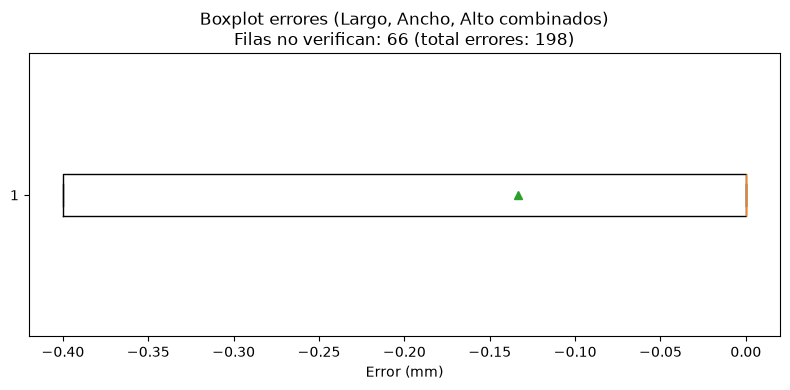

,caja_grosor_mm,caja_interior_largo,caja_interior_ancho,caja_interior_alto,caja_exterior_largo,caja_exterior_ancho,caja_exterior_alto,calculated_internal_largo,calculated_internal_ancho,calculated_internal_alto,verifica_largo,verifica_ancho,verifica_alto
0,4.1,386.0,286.0,303.0,394.2,294.2,311.2,386.0,286.0,303.0,True,True,True
1,2.7,395.0,296.0,260.0,400.0,301.4,265.4,394.6,296.0,260.0,False,True,True
2,4.1,388.0,288.0,164.0,396.2,296.2,172.2,388.0,288.0,164.0,True,True,True
3,2.7,395.0,296.0,224.0,400.0,301.4,229.4,394.6,296.0,224.0,False,True,True
4,4.1,386.0,286.0,253.0,394.2,294.2,261.2,386.0,286.0,253.0,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
422,4.1,383.0,248.0,234.0,391.2,256.2,242.2,383.0,248.0,234.0,True,True,True
423,4.1,383.0,248.0,234.0,391.2,256.2,242.2,383.0,248.0,234.0,True,True,True
424,2.7,395.0,296.0,173.0,400.0,301.4,178.4,394.6,296.0,173.0,False,True,True
425,2.7,393.0,255.0,204.0,398.4,260.4,209.4,393.0,255.0,204.0,True,True,True


In [95]:
df['calculated_internal_largo'] = df['caja_exterior_largo'] - 2*df['caja_grosor_mm']
df['calculated_internal_ancho'] = df['caja_exterior_ancho'] - 2*df['caja_grosor_mm']
df['calculated_internal_alto'] = df['caja_exterior_alto'] - 2*df['caja_grosor_mm']

# Revisar si todos verifican (si las dimensiones calculadas igualan a las del interior)
verifican_largo = (df['calculated_internal_largo'].round(1) == df['caja_interior_largo'].round(1))
verifican_ancho = (df['calculated_internal_ancho'].round(1) == df['caja_interior_ancho'].round(1))
verifican_alto  = (df['calculated_internal_alto'].round(1) == df['caja_interior_alto'].round(1))

df['verifica_largo'] = verifican_largo
df['verifica_ancho'] = verifican_ancho
df['verifica_alto']  = verifican_alto

# Obtener no verificados
no_verifican_mask = ~(verifican_largo & verifican_ancho & verifican_alto)
df_nov = df[no_verifican_mask]

import matplotlib.pyplot as plt
import numpy as np

if not df_nov.empty:
    # Calculo el error para cada dimensión
    df_nov = df_nov.copy()
    df_nov['error_largo'] = df_nov['calculated_internal_largo'] - df_nov['caja_interior_largo']
    df_nov['error_ancho'] = df_nov['calculated_internal_ancho'] - df_nov['caja_interior_ancho']
    df_nov['error_alto']  = df_nov['calculated_internal_alto'] - df_nov['caja_interior_alto']

    # Junto todos los errores en un solo array
    errores_todos = pd.concat([
        df_nov['error_largo'],
        df_nov['error_ancho'],
        df_nov['error_alto']
    ], ignore_index=True)

    # Calculo e imprimo estadísticos
    media = errores_todos.mean()
    mediana = errores_todos.median()
    desvio = errores_todos.std()
    print(f"Errores (unidos largo/ancho/alto):")
    print(f"Media: {media:.3f}")
    print(f"Mediana: {mediana:.3f}")
    print(f"Desvío estándar: {desvio:.3f}")

    # Un solo boxplot para todos los errores
    plt.figure(figsize=(8,4))
    plt.boxplot(errores_todos, vert=False, showmeans=True)
    plt.title(f'Boxplot errores (Largo, Ancho, Alto combinados)\nFilas no verifican: {len(df_nov)} (total errores: {len(errores_todos)})')
    plt.xlabel("Error (mm)")
    plt.tight_layout()
    plt.show()
else:
    print("Todos verifican")

df

<hr>

# Findings:

### COSTOS
Asumo
* costo_total: Costo por packaging
* costo_pallets_total: Costo por envio (150 USD x pallet verifica)

Costo total    = $209.235.094
freight cost   = $179.068.800
packiging cost = $30.166.294

Insights:
* El freight representa el 85.6% del costo total
* La principal palanca es el freight.
* Una reducción del 20% en packaging reduce el total en menos de un 3%
* Reduccion porcentual del 1% en freight es 5.94% de packaging

Hipotesis:
* Como nuestra palanca es bajar precio de Freight podriamos estar dispuestos a pagar más packaging para reducirlo

### DIMENSIONES

dim interna y externa
Por errores pequeños y observables en el 15% de las observaciones. Asumo error de redondeo

## Como reducimos freight?
### CAPACIDAD OCIOSA

Si bien las cajas se utilizan relativamente bien en promedio, existe un porcentaje significativo de uso inferior: muchos envíos utilizan menos del 84 % de la capacidad de las cajas, y las cajas individuales cerca del 65 %. Esto sugiere posibles ahorros mediante una mejor asignación del tamaño de las cajas, especialmente si el costo del flete depende del peso volumétrico.